# NB02: Within-Species AMR Variation Metrics

**Goal**: Classify each AMR gene as fixed/variable/rare within each species.
Compute diversity indices and cross-species variation patterns.

**Compute**: Local (10-20 min)

**Inputs**: `data/genome_amr_matrices/*.tsv` from NB01

**Outputs**:
- `data/amr_variation_by_species.csv` — per-species variation summary
- `data/amr_prevalence_by_gene.csv` — per-gene prevalence within each species

In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

PROJECT_DIR = Path(os.getcwd()).parent
ATLAS_DIR = PROJECT_DIR.parent / 'amr_pangenome_atlas'
DATA_DIR = PROJECT_DIR / 'data'
MATRIX_DIR = DATA_DIR / 'genome_amr_matrices'
FIG_DIR = PROJECT_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})

## 1. Load Atlas Data

In [2]:
species_summary = pd.read_csv(ATLAS_DIR / 'data' / 'amr_species_summary.csv')
amr_census = pd.read_csv(ATLAS_DIR / 'data' / 'amr_census.csv')
eligible = pd.read_csv(DATA_DIR / 'eligible_species.csv')

# Build AMR gene metadata lookup
amr_meta = amr_census[['gene_cluster_id', 'amr_gene', 'amr_product', 'mechanism',
                        'conservation_class', 'is_core', 'is_auxiliary', 'is_singleton']].drop_duplicates('gene_cluster_id')

print(f"Eligible species: {len(eligible)}")
print(f"AMR gene metadata: {len(amr_meta)} clusters")

Eligible species: 1307
AMR gene metadata: 82908 clusters


## 2. Compute Per-Gene Prevalence and Classification

In [3]:
def classify_prevalence(freq):
    """Classify AMR gene by within-species prevalence."""
    if freq >= 0.95:
        return 'fixed'
    elif freq <= 0.05:
        return 'rare'
    else:
        return 'variable'


def compute_species_metrics(matrix):
    """Compute variation metrics for one species matrix."""
    n_genomes = matrix.shape[0]
    n_amr = matrix.shape[1]
    
    # Per-gene prevalence
    prevalence = matrix.mean(axis=0)
    classes = prevalence.apply(classify_prevalence)
    
    n_fixed = (classes == 'fixed').sum()
    n_variable = (classes == 'variable').sum()
    n_rare = (classes == 'rare').sum()
    
    # Variability index: fraction of AMR genes that are variable
    variability_index = n_variable / n_amr if n_amr > 0 else 0
    
    # Mean pairwise Jaccard diversity
    if n_genomes >= 2:
        jaccard_dists = pdist(matrix.values, metric='jaccard')
        mean_jaccard = np.nanmean(jaccard_dists)
    else:
        mean_jaccard = np.nan
    
    # Shannon entropy of AMR gene frequencies
    # For each gene, entropy of its presence/absence across genomes
    gene_entropies = []
    for col in matrix.columns:
        p = prevalence[col]
        if 0 < p < 1:
            h = -p * np.log2(p) - (1-p) * np.log2(1-p)
        else:
            h = 0
        gene_entropies.append(h)
    mean_entropy = np.mean(gene_entropies)
    
    # AMR genes per genome stats
    amr_per_genome = matrix.sum(axis=1)
    
    return {
        'n_genomes': n_genomes,
        'n_amr': n_amr,
        'n_fixed': n_fixed,
        'n_variable': n_variable,
        'n_rare': n_rare,
        'variability_index': variability_index,
        'mean_jaccard': mean_jaccard,
        'mean_entropy': mean_entropy,
        'mean_amr_per_genome': amr_per_genome.mean(),
        'std_amr_per_genome': amr_per_genome.std(),
        'min_amr_per_genome': amr_per_genome.min(),
        'max_amr_per_genome': amr_per_genome.max(),
    }, prevalence, classes

In [4]:
# Process all species
species_metrics = []
gene_prevalence_rows = []

matrix_files = sorted(MATRIX_DIR.glob('*.tsv'))
print(f"Processing {len(matrix_files)} species matrices...")

for mf in matrix_files:
    species_id = mf.stem
    matrix = pd.read_csv(mf, sep='\t', index_col=0)
    
    if matrix.shape[0] < 2 or matrix.shape[1] < 1:
        continue
    
    metrics, prev, classes = compute_species_metrics(matrix)
    metrics['gtdb_species_clade_id'] = species_id
    species_metrics.append(metrics)
    
    # Per-gene prevalence records
    for gene_id in matrix.columns:
        gene_prevalence_rows.append({
            'gtdb_species_clade_id': species_id,
            'gene_cluster_id': gene_id,
            'prevalence': prev[gene_id],
            'prevalence_class': classes[gene_id],
        })

variation_df = pd.DataFrame(species_metrics)
prevalence_df = pd.DataFrame(gene_prevalence_rows)

print(f"Species with metrics: {len(variation_df)}")
print(f"Gene-species prevalence records: {len(prevalence_df)}")

Processing 1305 species matrices...


Species with metrics: 1305
Gene-species prevalence records: 37444


## 3. Merge with Atlas Metadata

In [5]:
# Merge species-level atlas info
variation_df = variation_df.merge(
    species_summary[['gtdb_species_clade_id', 'phylum', 'class', 'order', 'family',
                      'genus', 'openness', 'amr_density', 'pct_core_amr']],
    on='gtdb_species_clade_id', how='left'
)

# Merge gene-level atlas info
prevalence_df = prevalence_df.merge(
    amr_meta[['gene_cluster_id', 'amr_gene', 'mechanism', 'conservation_class']],
    on='gene_cluster_id', how='left'
)

# Save
variation_df.to_csv(DATA_DIR / 'amr_variation_by_species.csv', index=False)
prevalence_df.to_csv(DATA_DIR / 'amr_prevalence_by_gene.csv', index=False)

print(f"Saved amr_variation_by_species.csv: {len(variation_df)} rows")
print(f"Saved amr_prevalence_by_gene.csv: {len(prevalence_df)} rows")

Saved amr_variation_by_species.csv: 1305 rows
Saved amr_prevalence_by_gene.csv: 37444 rows


## 4. Analysis: Variation Landscape

/tmp/ipykernel_159460/4256620722.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


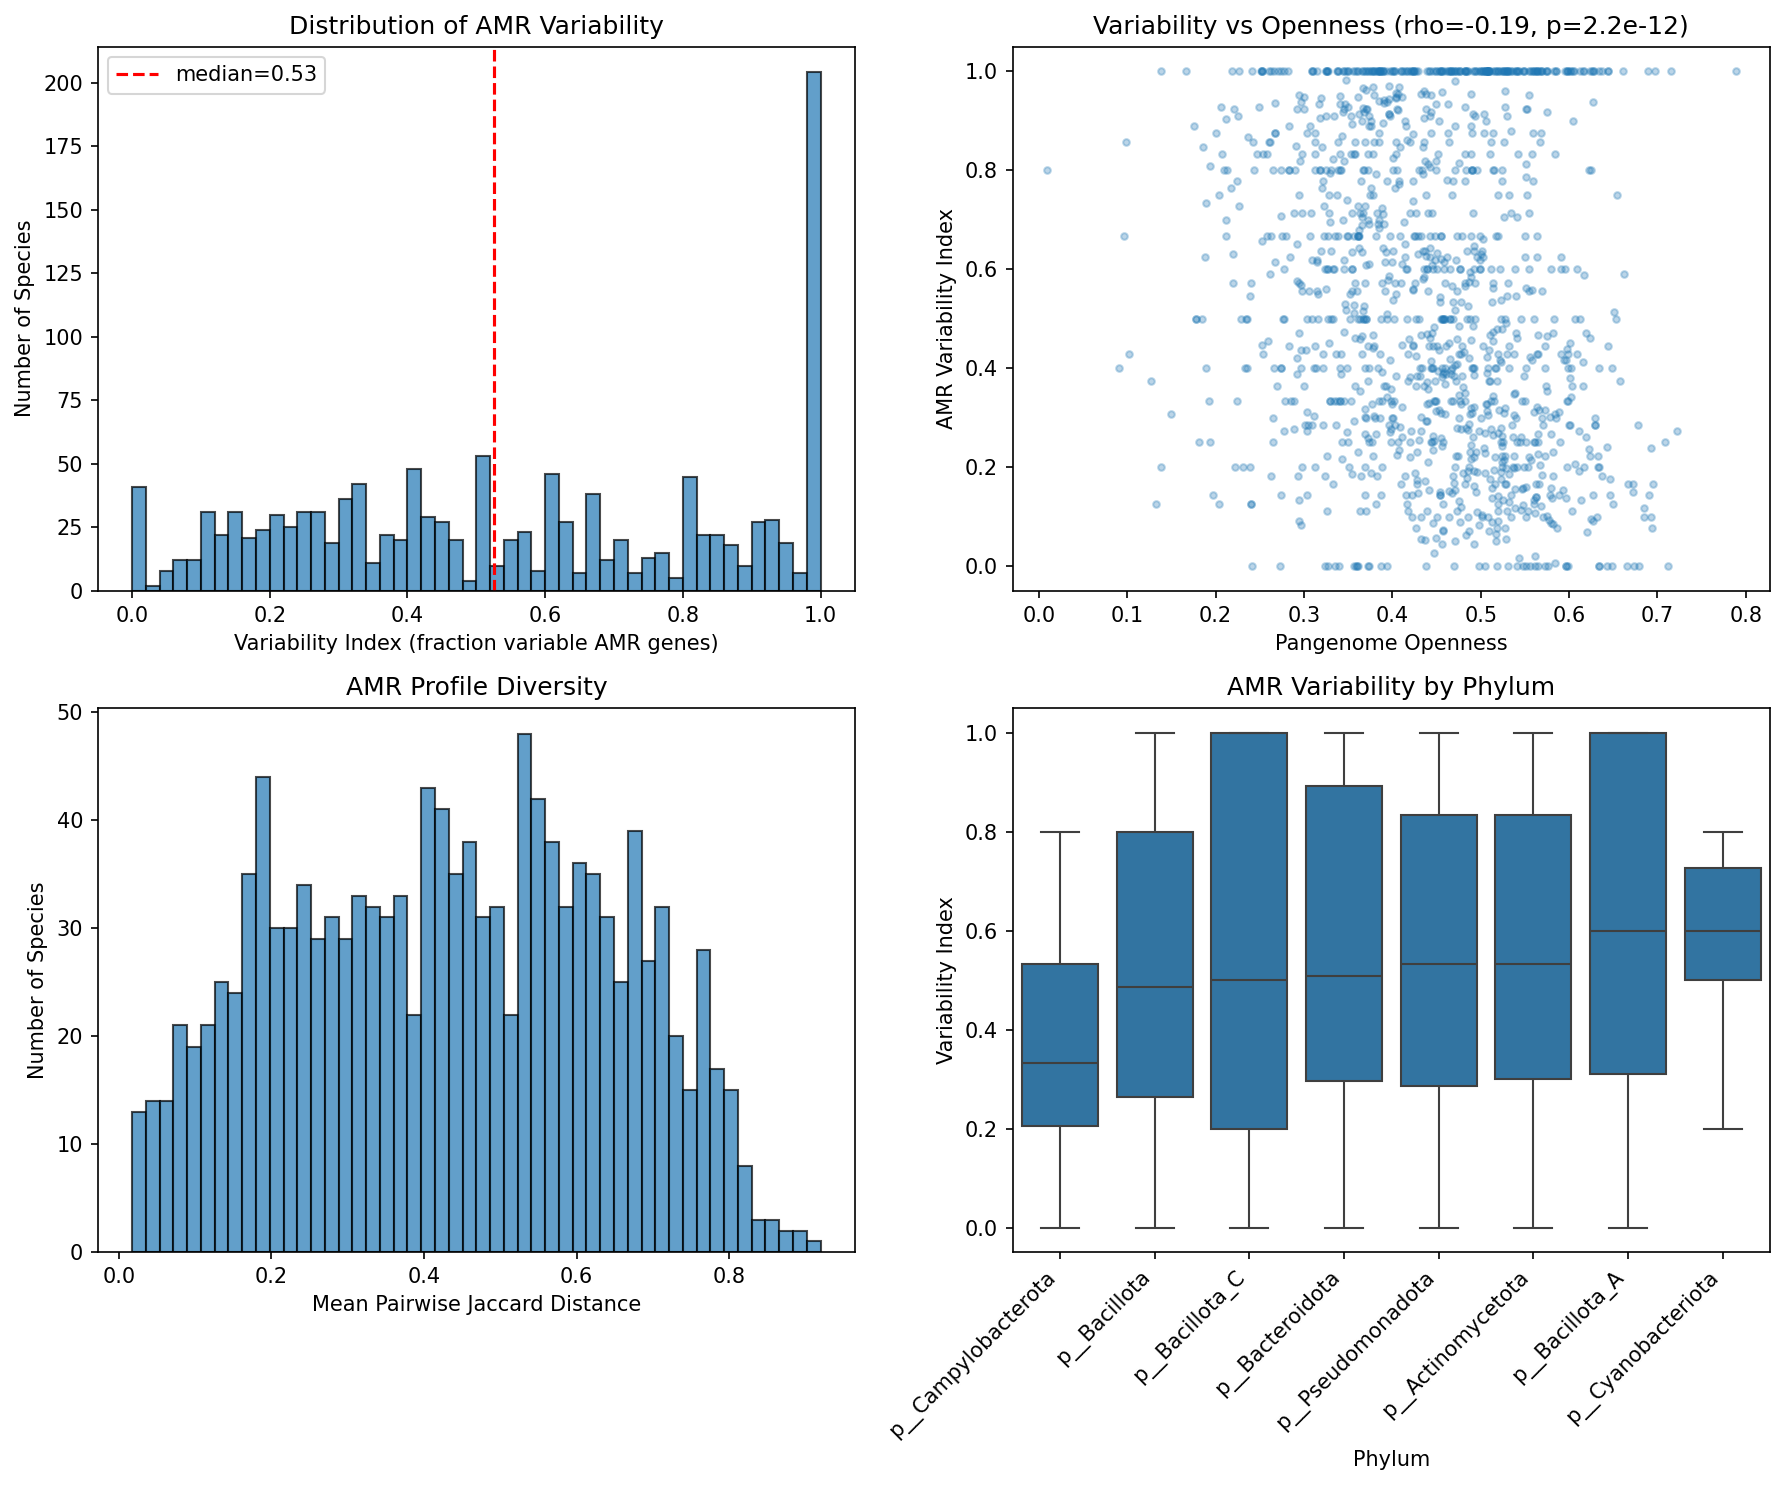

In [6]:
# Distribution of variability index
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 4a: Variability index histogram
ax = axes[0, 0]
ax.hist(variation_df['variability_index'], bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Variability Index (fraction variable AMR genes)')
ax.set_ylabel('Number of Species')
ax.set_title('Distribution of AMR Variability')
ax.axvline(variation_df['variability_index'].median(), color='red', ls='--',
           label=f"median={variation_df['variability_index'].median():.2f}")
ax.legend()

# 4b: Variability vs openness
ax = axes[0, 1]
ax.scatter(variation_df['openness'], variation_df['variability_index'],
           alpha=0.3, s=10)
r, p = stats.spearmanr(variation_df['openness'].dropna(), 
                        variation_df.loc[variation_df['openness'].notna(), 'variability_index'])
ax.set_xlabel('Pangenome Openness')
ax.set_ylabel('AMR Variability Index')
ax.set_title(f'Variability vs Openness (rho={r:.2f}, p={p:.1e})')

# 4c: Mean Jaccard diversity distribution
ax = axes[1, 0]
ax.hist(variation_df['mean_jaccard'].dropna(), bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Mean Pairwise Jaccard Distance')
ax.set_ylabel('Number of Species')
ax.set_title('AMR Profile Diversity')

# 4d: Fixed vs variable by phylum
ax = axes[1, 1]
top_phyla = variation_df['phylum'].value_counts().head(8).index
phylum_data = variation_df[variation_df['phylum'].isin(top_phyla)]
phylum_order = phylum_data.groupby('phylum')['variability_index'].median().sort_values().index
sns.boxplot(data=phylum_data, x='phylum', y='variability_index',
            order=phylum_order, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('Phylum')
ax.set_ylabel('Variability Index')
ax.set_title('AMR Variability by Phylum')

plt.tight_layout()
plt.savefig(FIG_DIR / 'nb02_variation_landscape.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Compare Within-Species Prevalence to Atlas Conservation Classes

In [7]:
# How does within-species prevalence relate to cross-species conservation class?
cross_tab = pd.crosstab(prevalence_df['conservation_class'], prevalence_df['prevalence_class'],
                         normalize='index')
print("Within-species prevalence class by atlas conservation class:")
print(cross_tab.round(3))
print()

# Chi-squared test
ct = pd.crosstab(prevalence_df['conservation_class'], prevalence_df['prevalence_class'])
chi2, p, dof, expected = stats.chi2_contingency(ct)
print(f"Chi-squared: {chi2:.1f}, p={p:.1e}, dof={dof}")
print(f"\nKey insight: Core genes in the atlas should predominantly be 'fixed' within species.")
print(f"Singleton genes should be predominantly 'rare' within species.")

Within-species prevalence class by atlas conservation class:
prevalence_class    fixed   rare  variable
conservation_class                        
Auxiliary           0.000  0.427     0.573
Core                0.773  0.000     0.227
Singleton           0.000  0.787     0.213

Chi-squared: 33099.6, p=0.0e+00, dof=4

Key insight: Core genes in the atlas should predominantly be 'fixed' within species.
Singleton genes should be predominantly 'rare' within species.


In [8]:
# Prevalence by mechanism
mech_prev = prevalence_df.groupby('mechanism')['prevalence'].agg(['mean', 'median', 'count'])
mech_prev = mech_prev[mech_prev['count'] >= 10].sort_values('median', ascending=False)
print("Median within-species prevalence by AMR mechanism:")
print(mech_prev.round(3))

Median within-species prevalence by AMR mechanism:
                         mean  median  count
mechanism                                   
Cell wall modification  0.219   0.067   1284
Regulatory              0.151   0.056   1874
Efflux                  0.218   0.056   7210
Beta-lactamase          0.286   0.050   3999
Other/Unclassified      0.178   0.050   9781
Oxidoreductase          0.140   0.050   3083
Target modification     0.137   0.043   3102
Ribosomal               0.103   0.042     24
Enzymatic inactivation  0.145   0.037   7087


In [9]:
# Summary statistics
print("="*60)
print("NB02 SUMMARY")
print("="*60)
print(f"Species analyzed: {len(variation_df)}")
print(f"Gene-species records: {len(prevalence_df)}")
print(f"")
print(f"Variability index: {variation_df['variability_index'].median():.3f} median")
print(f"Mean Jaccard diversity: {variation_df['mean_jaccard'].median():.3f} median")
print(f"Mean entropy: {variation_df['mean_entropy'].median():.3f} median")
print(f"")
print(f"Prevalence class distribution:")
print(prevalence_df['prevalence_class'].value_counts().to_string())
print(f"")
print(f"Variability-openness correlation: rho={r:.3f}, p={p:.1e}")

NB02 SUMMARY
Species analyzed: 1305
Gene-species records: 37444

Variability index: 0.526 median
Mean Jaccard diversity: 0.435 median
Mean entropy: 0.364 median

Prevalence class distribution:
prevalence_class
rare        19198
variable    15454
fixed        2792

Variability-openness correlation: rho=-0.193, p=0.0e+00
